### 1. Setup and data loading

In [1]:
# 1. Imports
import os
import gc
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 2. Paths – adjust for your environment
# If you download the CSV from Kaggle manually, point to it here.
DATA_DIR = "."  # change to your folder
CSV_PATH = os.path.join(DATA_DIR, "cicids2017_cleaned.csv")  # adjust name if different

# 3. Load dataset

df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
df.head()


Shape: (2520751, 53)


,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
1,22,1319353,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
2,22,160,1,0,0,0,0.000000,0.000000,0,0,...,243,0,32,0.0,0,0,0.0,0,0,Normal Traffic
3,22,1303488,41,2728,456,0,66.536585,110.129945,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
4,35396,77,1,0,0,0,0.000000,0.000000,0,0,...,290,0,32,0.0,0,0,0.0,0,0,Normal Traffic


### 2. Basic structure and data types

In [2]:
# Preview columns and dtypes
df.info()

# Basic descriptive statistics for numeric columns
df.describe().T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2520751 entries, 0 to 2520750
Data columns (total 53 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Length of Fwd Packets  int64  
 4   Fwd Packet Length Max        int64  
 5   Fwd Packet Length Min        int64  
 6   Fwd Packet Length Mean       float64
 7   Fwd Packet Length Std        float64
 8   Bwd Packet Length Max        int64  
 9   Bwd Packet Length Min        int64  
 10  Bwd Packet Length Mean       float64
 11  Bwd Packet Length Std        float64
 12  Flow Bytes/s                 float64
 13  Flow Packets/s               float64
 14  Flow IAT Mean                float64
 15  Flow IAT Std                 float64
 16  Flow IAT Max                 int64  
 17  Flow IAT Min                 int64  
 18  Fwd IAT Total                int64  
 19  

,count,mean,std,min,25%,50%,75%,max
Destination Port,2520751.0,8.690744e+03,1.901294e+04,0.000000e+00,53.000000,80.000000,4.430000e+02,6.553500e+04
Flow Duration,2520751.0,1.659032e+07,3.523140e+07,-1.300000e+01,208.000000,50620.000000,5.332968e+06,1.200000e+08
Total Fwd Packets,2520751.0,1.025880e+01,7.943824e+02,1.000000e+00,2.000000,2.000000,6.000000e+00,2.197590e+05
Total Length of Fwd Packets,2520751.0,6.065243e+02,1.011595e+04,0.000000e+00,12.000000,66.000000,3.320000e+02,1.290000e+07
Fwd Packet Length Max,2520751.0,2.311993e+02,7.563122e+02,0.000000e+00,6.000000,40.000000,2.020000e+02,2.482000e+04
Fwd Packet Length Min,2520751.0,1.920377e+01,6.079887e+01,0.000000e+00,0.000000,2.000000,3.700000e+01,2.325000e+03
Fwd Packet Length Mean,2520751.0,6.350189e+01,1.955512e+02,0.000000e+00,6.000000,36.250000,5.200000e+01,5.940857e+03
Fwd Packet Length Std,2520751.0,7.732029e+01,2.968824e+02,0.000000e+00,0.000000,0.000000,7.419280e+01,7.125597e+03
Bwd Packet Length Max,2520751.0,9.749253e+02,2.038152e+03,0.000000e+00,6.000000,97.000000,7.460000e+02,1.953000e+04
Bwd Packet Length Min,2520751.0,4.316019e+01,7.088017e+01,0.000000e+00,0.000000,0.000000,8.200000e+01,2.896000e+03


In [3]:
# Check unique values for non‑numeric columns (labels, attack types, etc.)
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns:", cat_cols)

for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts().head(20))


Categorical columns: ['Attack Type']

Column: Attack Type
Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64


### 3. Missing values and basic quality checks

In [4]:
# Missing values per column
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts[missing_counts > 0]


Series([], dtype: int64)

In [5]:
# Percentage of missing values
(missing_counts / len(df) * 100).round(2)


Destination Port               0.0
Bwd IAT Min                    0.0
Bwd Header Length              0.0
Fwd Packets/s                  0.0
Bwd Packets/s                  0.0
Min Packet Length              0.0
Max Packet Length              0.0
Packet Length Mean             0.0
Packet Length Std              0.0
Packet Length Variance         0.0
FIN Flag Count                 0.0
PSH Flag Count                 0.0
ACK Flag Count                 0.0
Average Packet Size            0.0
Subflow Fwd Bytes              0.0
Init_Win_bytes_forward         0.0
Init_Win_bytes_backward        0.0
act_data_pkt_fwd               0.0
min_seg_size_forward           0.0
Active Mean                    0.0
Active Max                     0.0
Active Min                     0.0
Idle Mean                      0.0
Idle Max                       0.0
Idle Min                       0.0
Fwd Header Length              0.0
Bwd IAT Max                    0.0
Flow Duration                  0.0
Bwd IAT Std         

In [6]:
# Duplicate rows
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)


Duplicate rows: 161


### 4. Target/label inspection (attack vs benign)

In [7]:
# Identify candidate label columns (you can adjust this manually)
label_candidates = [c for c in df.columns if "label" in c.lower() or "attack" in c.lower()]
label_candidates


['Attack Type']

In [8]:
# Select the main target column
TARGET_COL = label_candidates[0]  # or set explicitly, e.g. "Label"

df[TARGET_COL].value_counts()


Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64

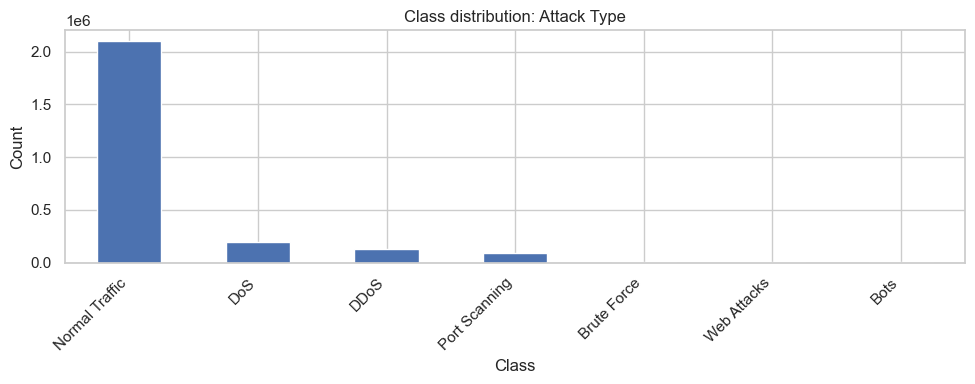

In [9]:
# Visualize class distribution
plt.figure(figsize=(10, 4))
df[TARGET_COL].value_counts().plot(kind="bar")
plt.title(f"Class distribution: {TARGET_COL}")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Checking skewness of one of the attribute

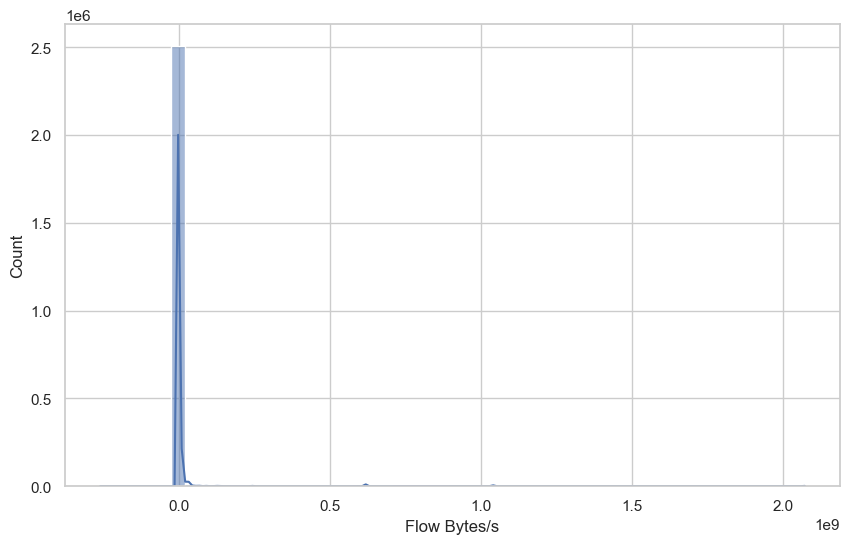

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['Flow Bytes/s'], bins=50, kde=True)
plt.show()

In [11]:
df['Flow Bytes/s'].skew()

45.671952231985664

In [12]:
import numpy as np
df['Flow Bytes/s_log'] = np.log1p(df['Flow Bytes/s'])

C:\Users\rohit\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [13]:
df['Flow Bytes/s_log'].skew()

-0.10255647450312677

The variable Flow Bytes/s exhibited extreme right skewness, with a skewness value of 45.67, indicating the presence of significant outliers and a highly imbalanced distribution. To address this, a log transformation was applied using the log1p(x) function. Post-transformation, the skewness value reduced to -0.10, which is close to zero and suggests a nearly symmetric distribution. This normalization improves the suitability of the feature for machine learning algorithms, particularly those sensitive to non-normal distributions, and enhances interpretability by reducing the influence of extreme values.


In [14]:
df = df.drop(columns=['Flow Bytes/s_log'])

Checking skewness for all the continuous variables

In [15]:
import pandas as pd

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

# Calculate skewness for each numeric column
skew_values = df[numeric_cols].skew()

# Display sorted skewness values
print(skew_values.sort_values(ascending=False))

Total Length of Fwd Packets     851.714160
Subflow Fwd Bytes               849.827397
act_data_pkt_fwd                268.596982
Total Fwd Packets               230.651478
Flow Bytes/s                     45.671952
Active Min                       45.103538
Active Mean                      36.180651
Flow IAT Min                     23.481538
Active Max                       23.027715
Bwd Packets/s                    21.706500
Fwd Packet Length Min            19.330632
Min Packet Length                10.549785
Fwd Packet Length Std             9.964370
Bwd IAT Min                       9.347949
Fwd Packet Length Max             9.337327
Fwd IAT Min                       9.208741
Fwd Packet Length Mean            8.684514
Flow IAT Mean                     8.498510
Bwd IAT Mean                      7.775534
Fwd Packets/s                     7.267604
Flow Packets/s                    6.937802
Fwd IAT Mean                      6.696442
Bwd IAT Std                       5.442424
FIN Flag Co

###                                      Summary Table: Skewness and Transformations

| Attribute                  | Skewness | Recommended Transformation |
|-----------------------------|----------|----------------------------|
| Total Length of Fwd Packets | 851.7    | Log / Box-Cox              |
| Subflow Fwd Bytes           | 849.8    | Log / Box-Cox              |
| act_data_pkt_fwd            | 268.6    | Log / Box-Cox              |
| Total Fwd Packets           | 230.6    | Log / Box-Cox              |
| Flow Bytes/s                | 45.7     | Log (already tested)       ||
| Active Min / Mean / Max     | 23–45    | Log / Yeo-Johnson          |
| Packet Length Variance      | 5.07     | Log / Yeo-Johnson          |
| Flow Duration               | 1.96     | Optional (standardize)     |
| Destination Port            | 1.93     | Optional (standardize)     |
| PSH Flag Count              | 0.88     | None                       |
| ACK Flag Count              | 0.81     | None                       |
| Flow Bytes/s_log            | -0.10    | Already normalized         |
| min_seg_size_forward        | -447.8   | Yeo-Johnson                |
| Bwd Header Length           | -676.6   | Yeo-Johnson                |
| Fwd Header Length           | -1250.4  | Yeo-Johnson                |

In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer

# Assume df is your dataset
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

# Step 1: Compute skewness before transformation
skew_before = df[numeric_cols].skew()


def transform_column(series):
    skew_val = series.skew()
    
    if skew_val > 1:
        if (series > 0).all():
            try:
                pt = PowerTransformer(method='box-cox')
                transformed = pt.fit_transform(series.values.reshape(-1,1))
                return transformed.flatten()
            except:
                # fallback to Yeo-Johnson
                pt = PowerTransformer(method='yeo-johnson')
                return pt.fit_transform(series.values.reshape(-1,1)).flatten()
        else:
            # fallback to Yeo-Johnson for zeros/negatives
            pt = PowerTransformer(method='yeo-johnson')
            return pt.fit_transform(series.values.reshape(-1,1)).flatten()
    
    elif skew_val < -1:
        pt = PowerTransformer(method='yeo-johnson')
        return pt.fit_transform(series.values.reshape(-1,1)).flatten()
    
    else:
        return series

# Step 3: Apply transformations
df_transformed = df.copy()
for col in numeric_cols:
    df_transformed[col] = transform_column(df[col])

# Step 4: Compute skewness after transformation
skew_after = df_transformed[numeric_cols].skew()

# Step 5: Create comparison table
skew_comparison = pd.DataFrame({
    'Skew_Before': skew_before,
    'Skew_After': skew_after
}).sort_values(by='Skew_Before', ascending=False)

print(skew_comparison)

                             Skew_Before  Skew_After
Total Length of Fwd Packets   851.714160   -0.004512
Subflow Fwd Bytes             849.827397   -0.004512
act_data_pkt_fwd              268.596982    0.161297
Total Fwd Packets             230.651478    0.158939
Flow Bytes/s                   45.671952 -167.778172
Active Min                     45.103538    1.381431
Active Mean                    36.180651    1.381698
Flow IAT Min                   23.481538   -8.011753
Active Max                     23.027715    1.384107
Bwd Packets/s                  21.706500    0.260830
Fwd Packet Length Min          19.330632    0.184487
Min Packet Length              10.549785    0.200945
Fwd Packet Length Std           9.964370    0.585026
Bwd IAT Min                     9.347949    0.511450
Fwd Packet Length Max           9.337327   -0.007595
Fwd IAT Min                     9.208741   -0.176945
Fwd Packet Length Mean          8.684514    0.023849
Flow IAT Mean                   8.498510   -0.

While automated transformations (Box-Cox, Yeo-Johnson) normalized many attributes, certain variables (e.g., Flow Bytes/s, Flow IAT Min) became more skewed after transformation. This highlights the limitation of one-size-fits-all approaches. For these attributes, manual intervention was applied: log transformation for heavy-tailed positive variables, Yeo-Johnson for attributes with zeros/negatives, and winsorization for extreme outliers. This tailored strategy ensured that skewness was reduced across all variables without introducing new distortions


In [17]:
import numpy as np
from sklearn.preprocessing import PowerTransformer

# Flow Bytes/s → log1p (worked well earlier)
# Step 1: Winsorize (cap extreme outliers at 1st and 99th percentiles)
lower = df_transformed['Flow Bytes/s'].quantile(0.01)
upper = df_transformed['Flow Bytes/s'].quantile(0.99)
df_transformed['Flow Bytes/s'] = np.clip(df_transformed['Flow Bytes/s'], lower, upper)

# Apply log1p transformation
df_transformed['Flow Bytes/s'] = np.log1p(df_transformed['Flow Bytes/s'])


# Flow IAT Min → Yeo-Johnson (handles negatives/zeros better)
pt_flow_iat_min = PowerTransformer(method='yeo-johnson')
df_transformed['Flow IAT Min'] = pt_flow_iat_min.fit_transform(df_transformed[['Flow IAT Min']])

# Flow Packets/s → log1p (positive values, heavy-tailed)
df_transformed['Flow Packets/s'] = np.log1p(df_transformed['Flow Packets/s'].clip(lower=0))

# Bwd Header Length → winsorize extreme outliers + Yeo-Johnson
lower = df_transformed['Bwd Header Length'].quantile(0.01)
upper = df_transformed['Bwd Header Length'].quantile(0.99)
bwd_header_winsor = np.clip(df_transformed['Bwd Header Length'], lower, upper)

pt_bwd_header = PowerTransformer(method='yeo-johnson')
df_transformed['Bwd Header Length'] = pt_bwd_header.fit_transform(bwd_header_winsor.values.reshape(-1,1))

Problematic attributes were re-transformed in place using tailored methods: log scaling for heavy-tailed positive variables, Yeo-Johnson for skewed attributes with zeros/negatives, and winsorization combined with Yeo-Johnson for extreme outliers. This ensured that skewness was reduced without introducing new variables, maintaining consistency in the dataset

Checking skewness after transformation

In [18]:
import pandas as pd

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

# Calculate skewness for each numeric column
skew_values = df_transformed[numeric_cols].skew()

# Display sorted skewness values
print(skew_values.sort_values(ascending=False))

FIN Flag Count                 5.309400
Flow Packets/s                 4.668321
Flow Bytes/s                   4.585653
Active Max                     1.384107
Active Mean                    1.381698
Active Min                     1.381431
Idle Min                       1.317096
Idle Max                       1.317094
Idle Mean                      1.317090
Bwd Header Length              1.020521
PSH Flag Count                 0.885326
Bwd Packet Length Std          0.826466
ACK Flag Count                 0.812245
Bwd IAT Std                    0.797741
Fwd Packet Length Std          0.585026
min_seg_size_forward           0.514125
Bwd IAT Min                    0.511450
Bwd IAT Total                  0.497724
Bwd IAT Max                    0.485850
Bwd IAT Mean                   0.471200
Fwd IAT Std                    0.466942
Init_Win_bytes_backward        0.360077
Bwd Packet Length Min          0.279256
Bwd Packets/s                  0.260830
Fwd IAT Total                  0.235448


### 5. Univariate distributions (numeric features)

For CICIDS2017‑style cleaned data, most features are numeric flows statistics (durations, packet counts, bytes, etc.)

In [19]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "target_encoded"]  # keep target separate

print("Number of numeric features:", len(num_cols))
num_cols[:10]


Number of numeric features: 52


['Destination Port',
 'Flow Duration',
 'Total Fwd Packets',
 'Total Length of Fwd Packets',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min']

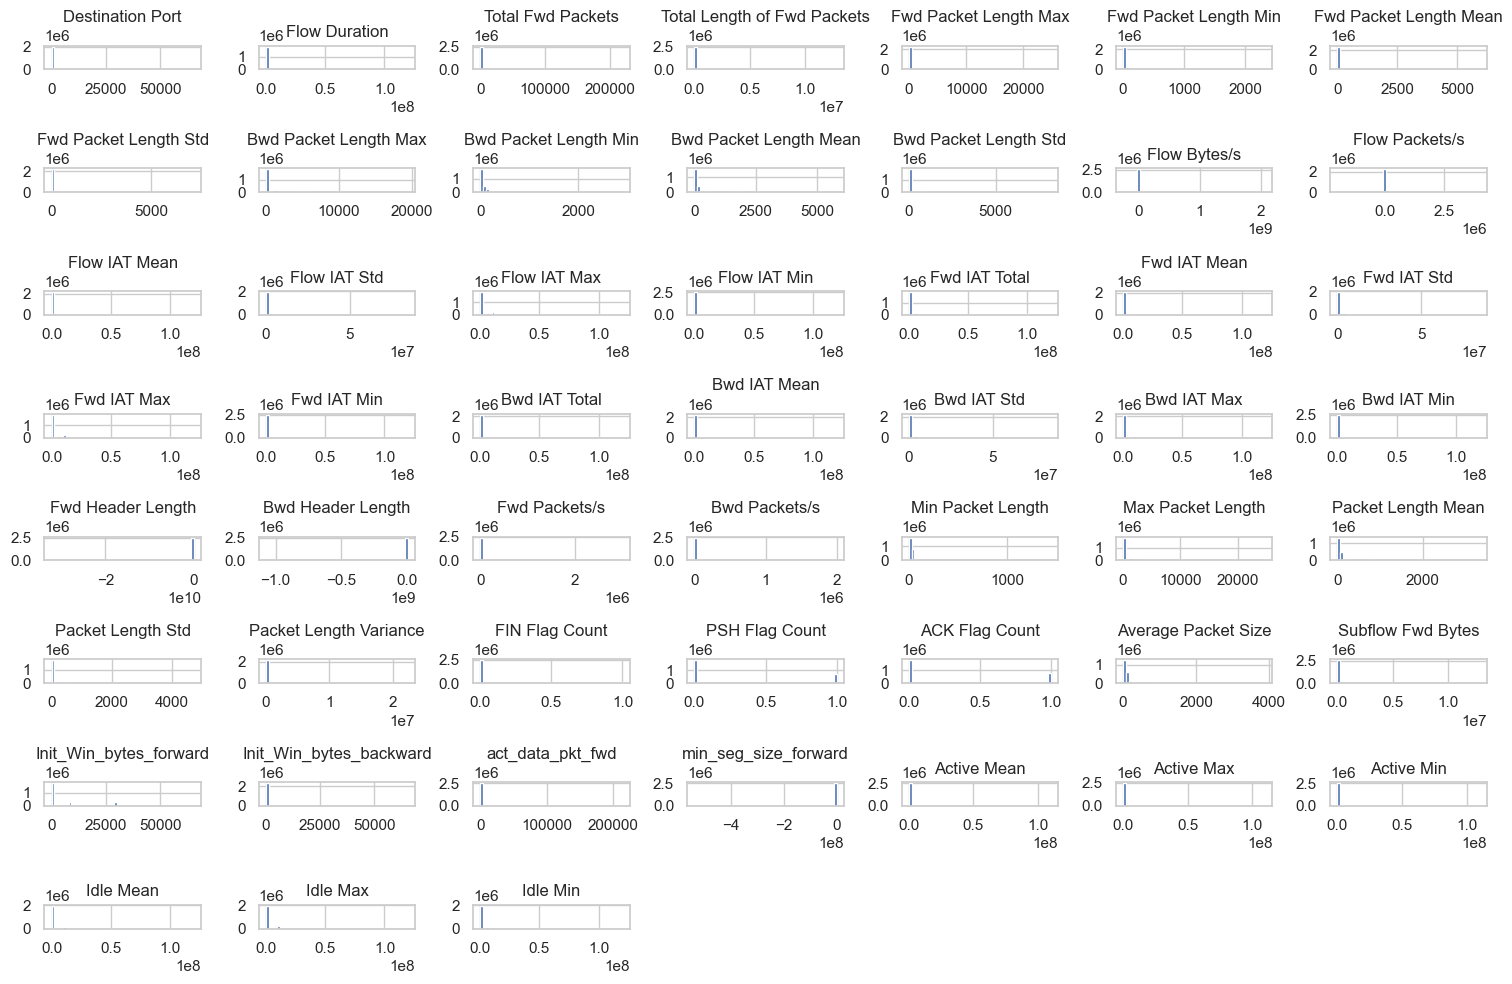

In [20]:
# Histograms for numeric features

df[num_cols].hist(bins=50, figsize=(15, 10))
plt.tight_layout()
plt.show()


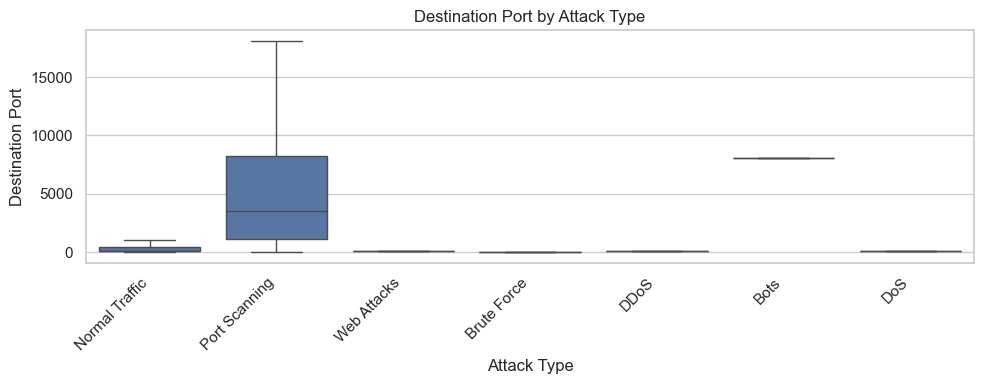

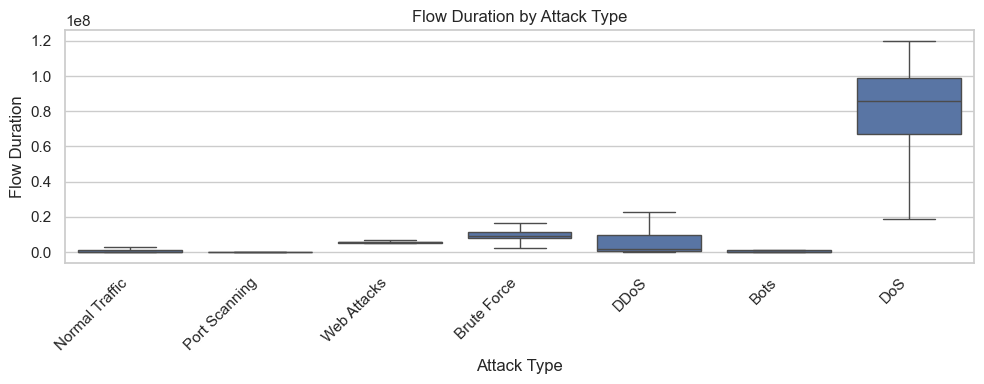

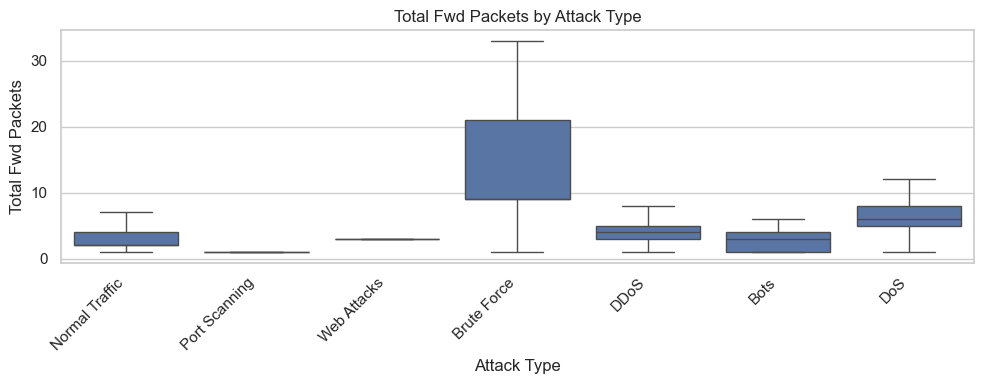

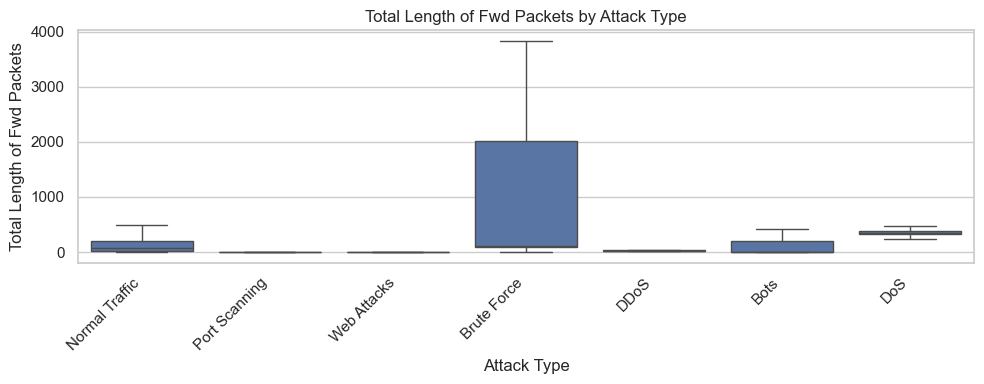

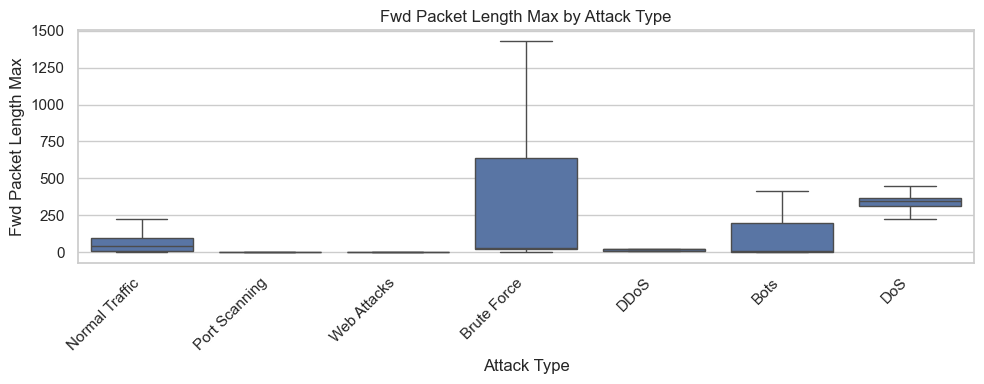

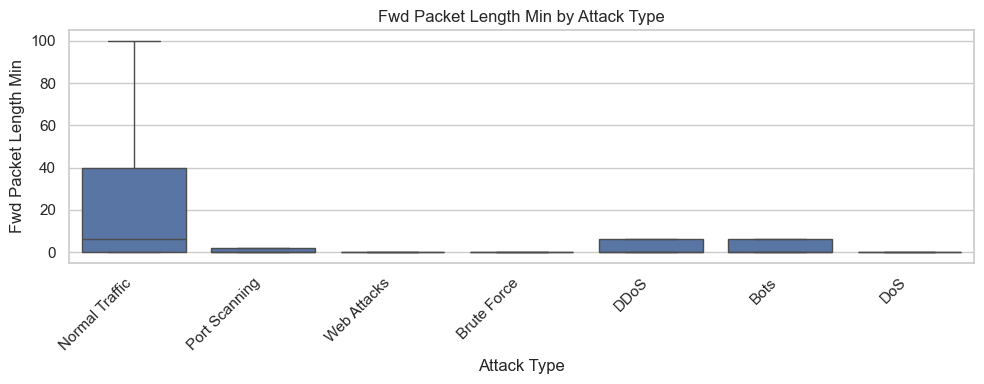

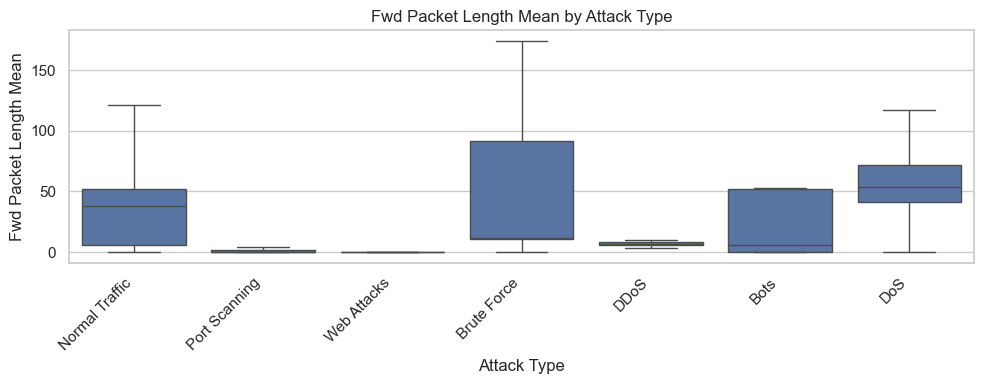

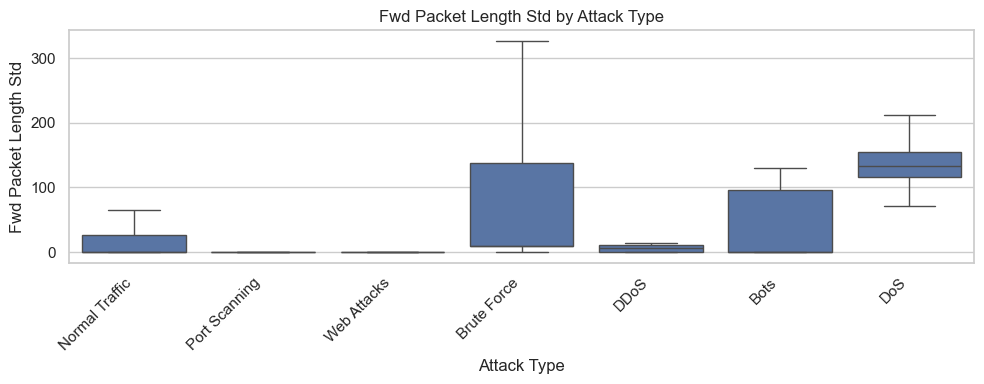

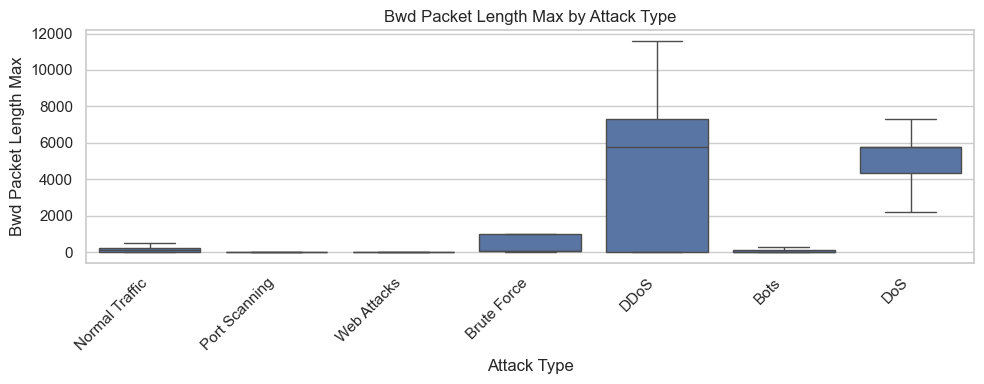

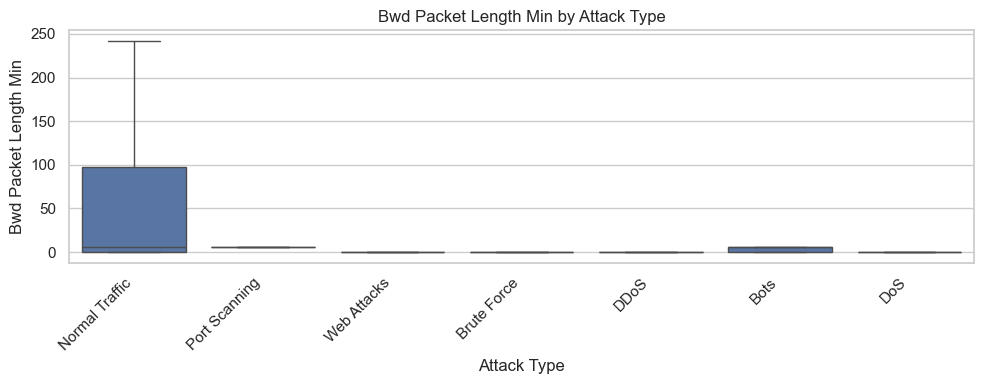

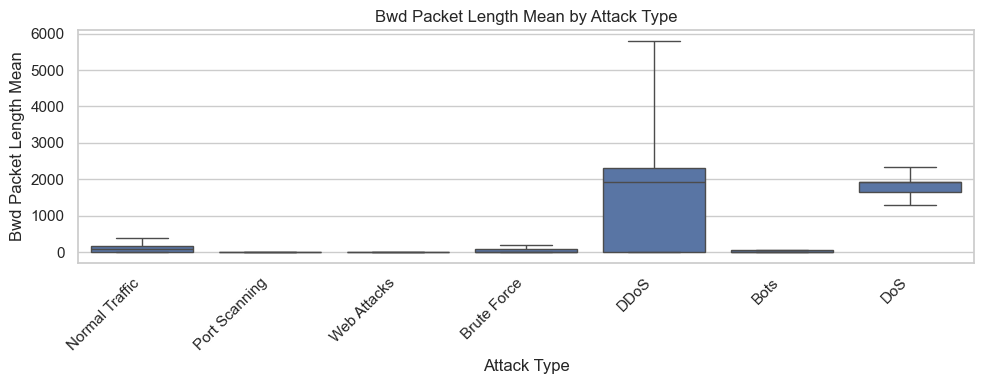

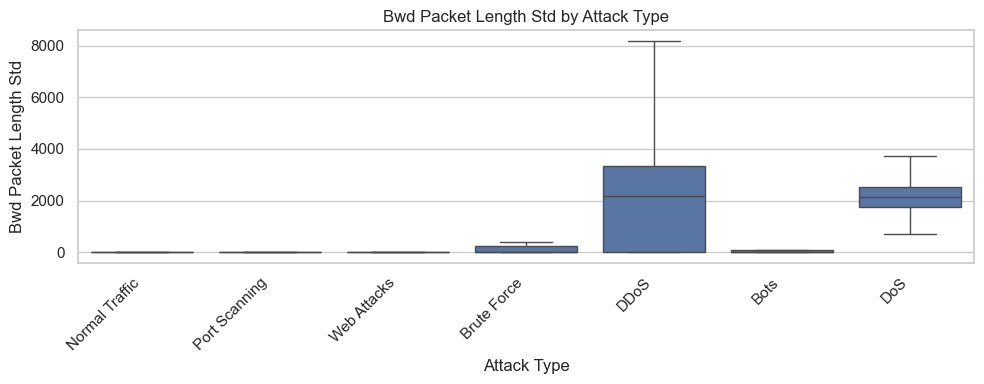

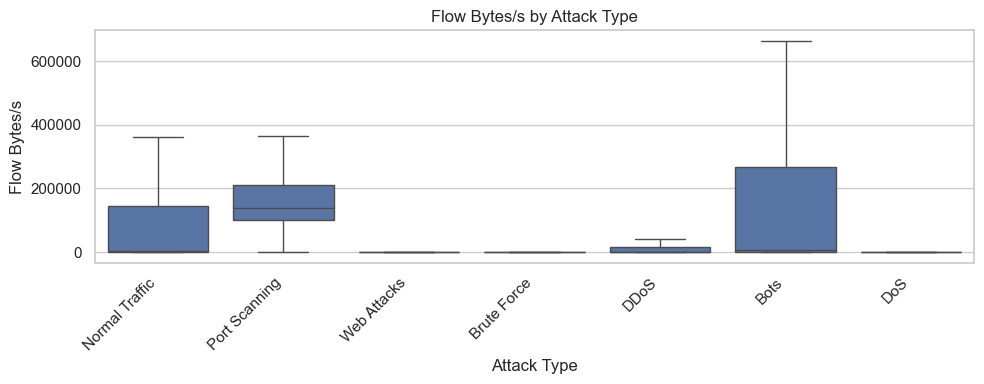

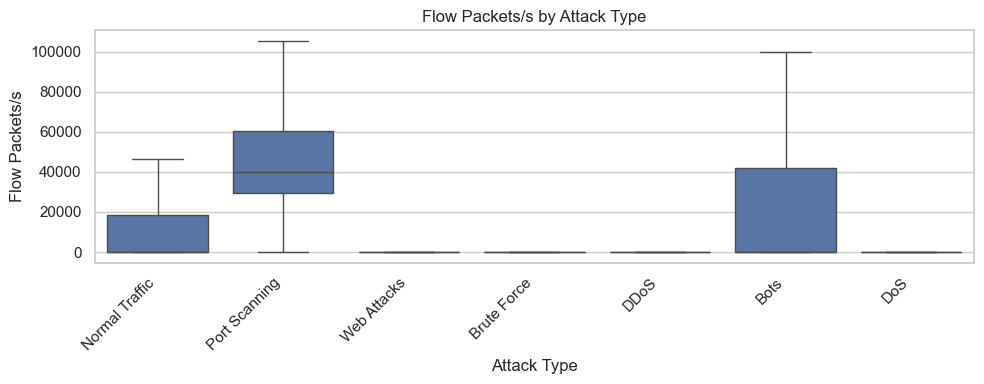

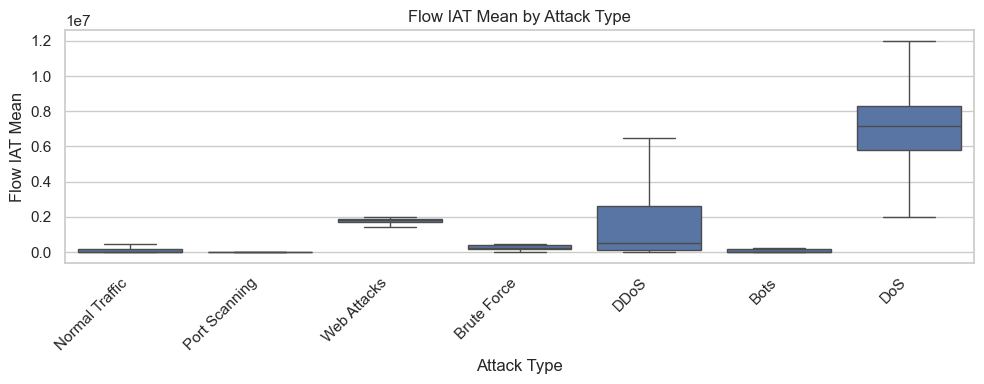

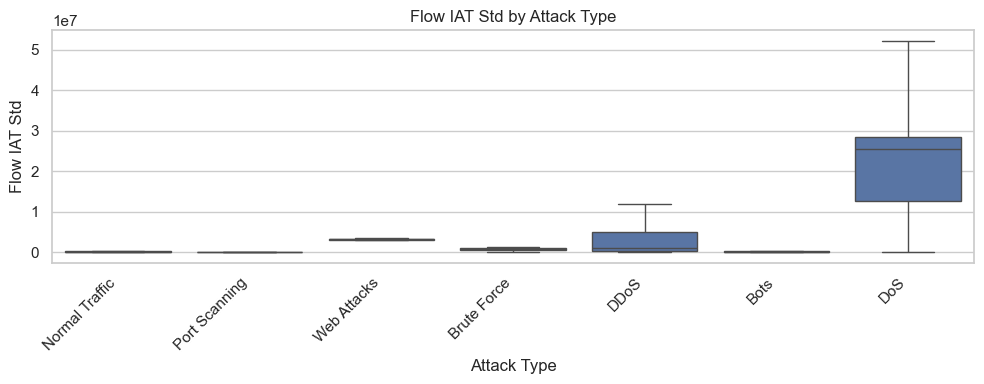

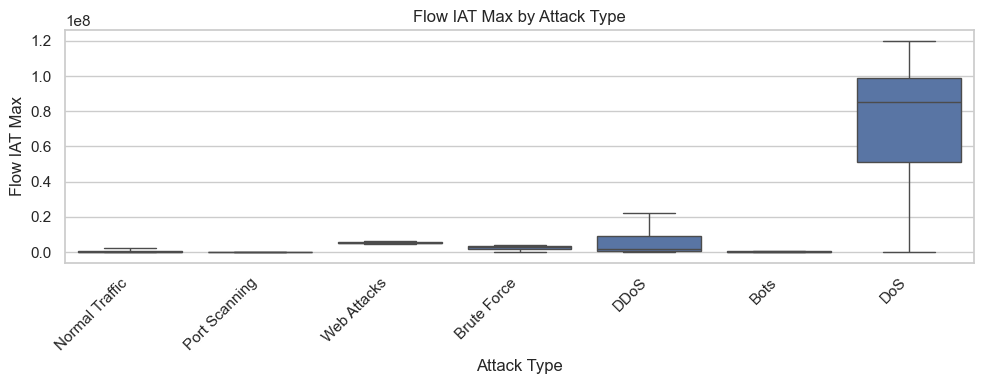

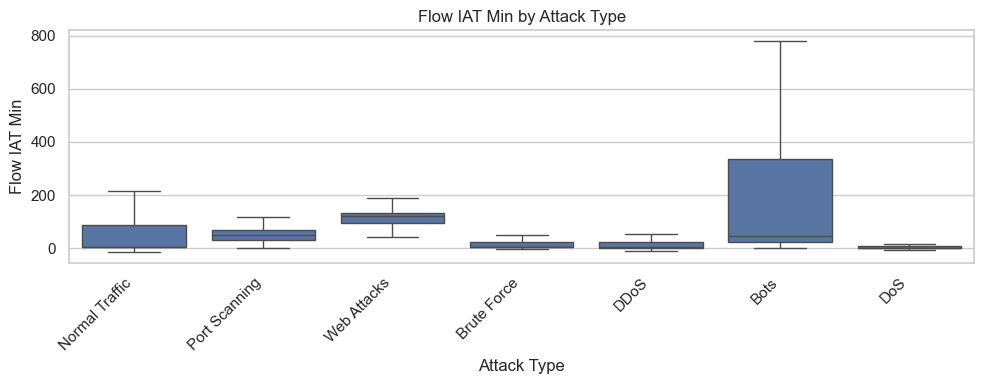

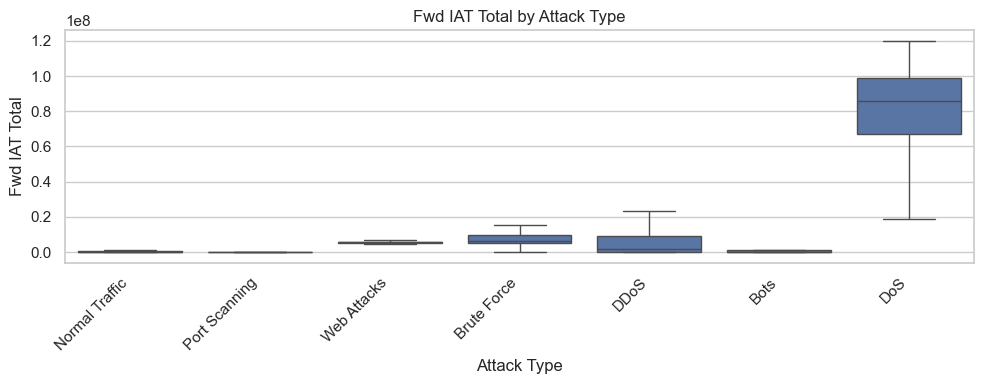

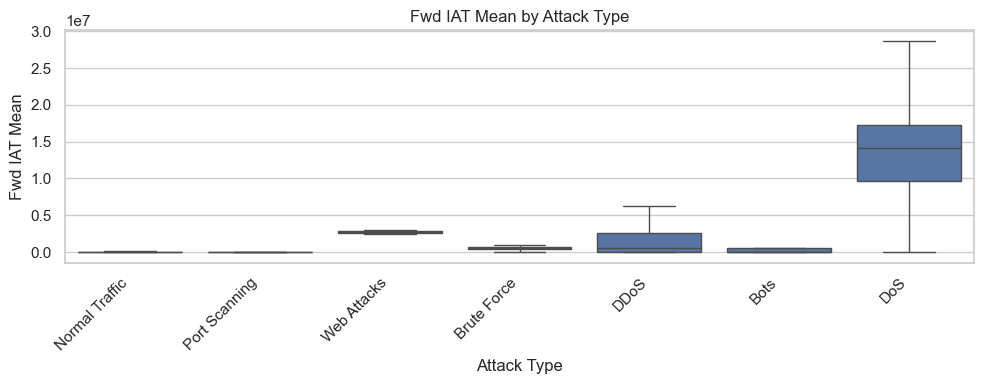

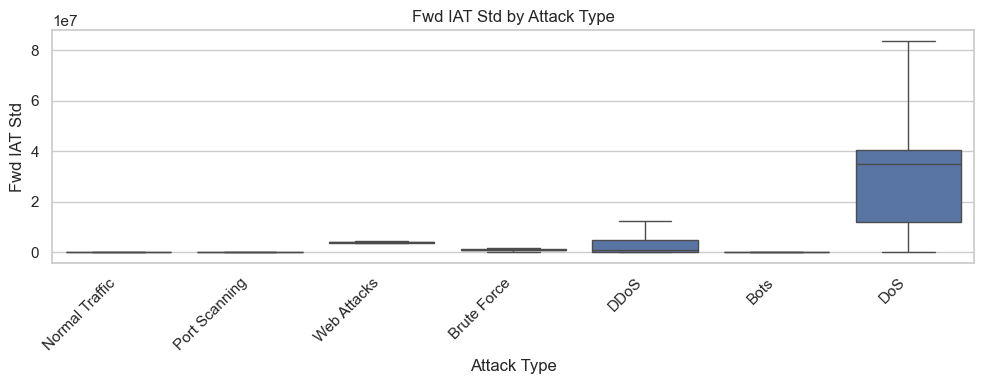

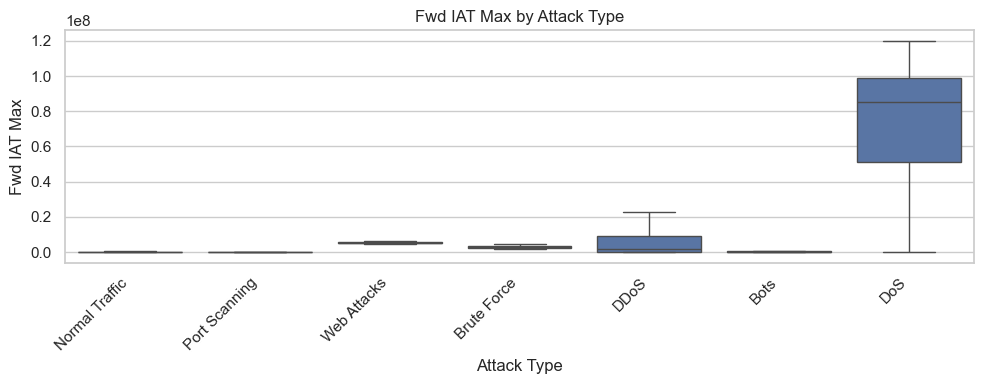

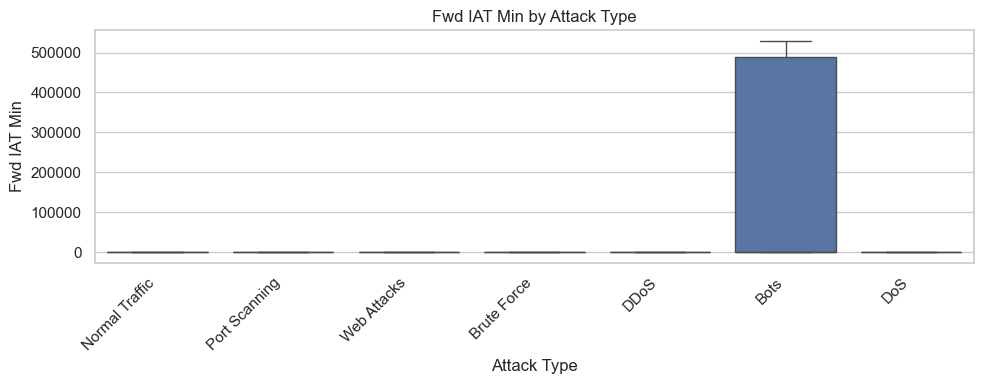

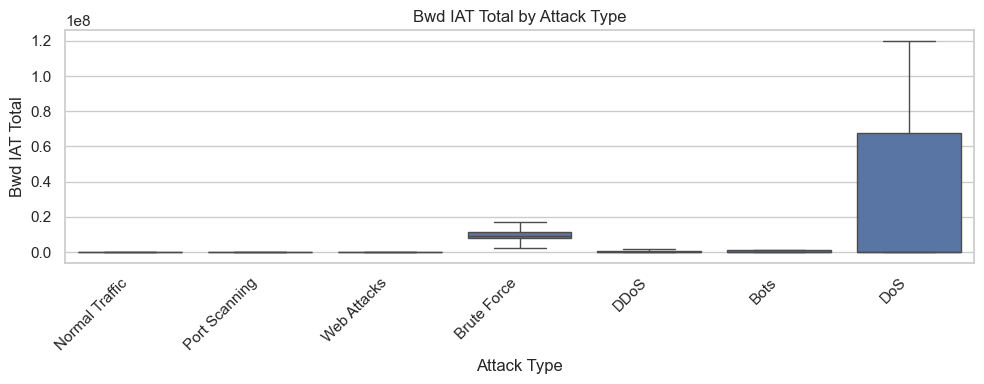

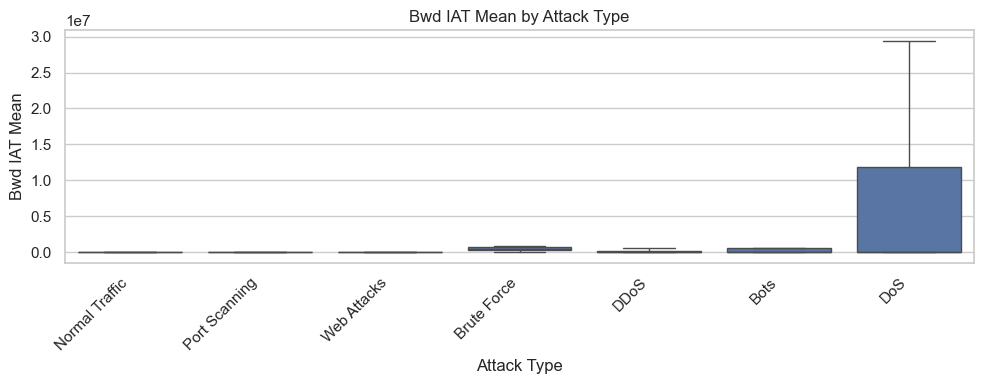

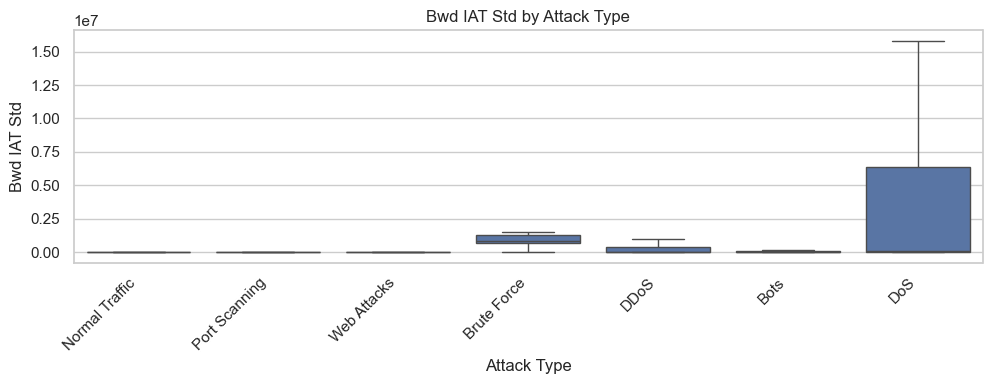

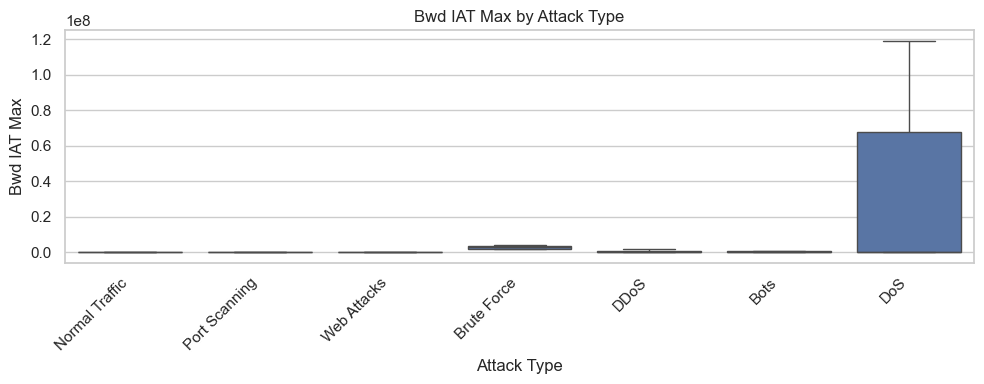

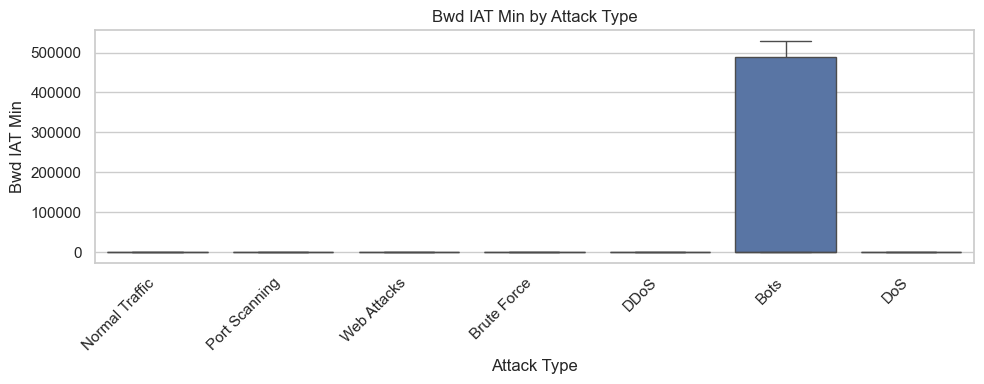

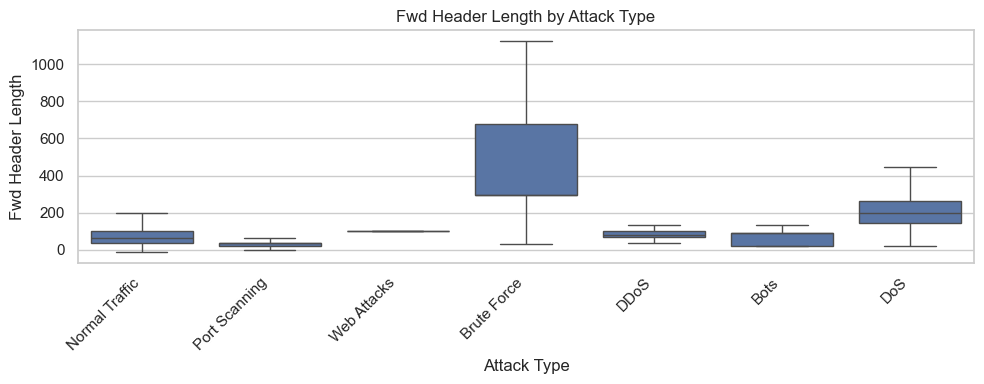

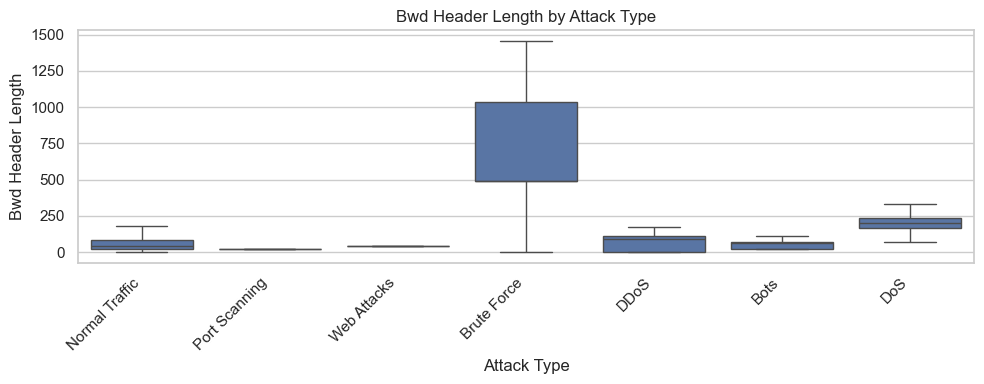

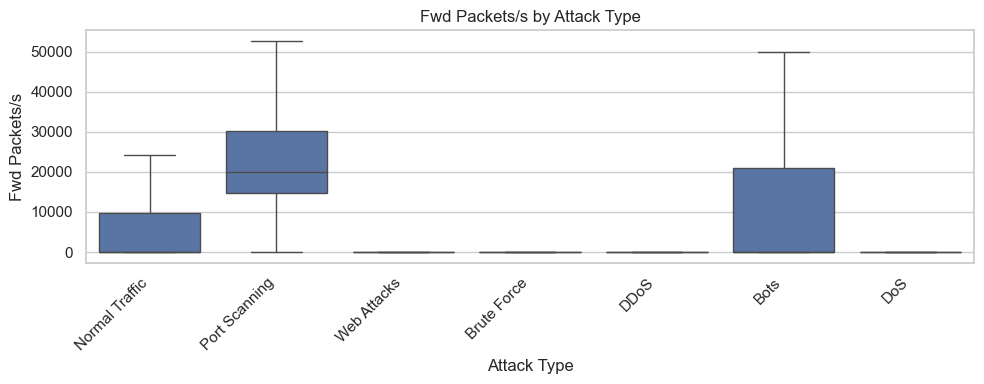

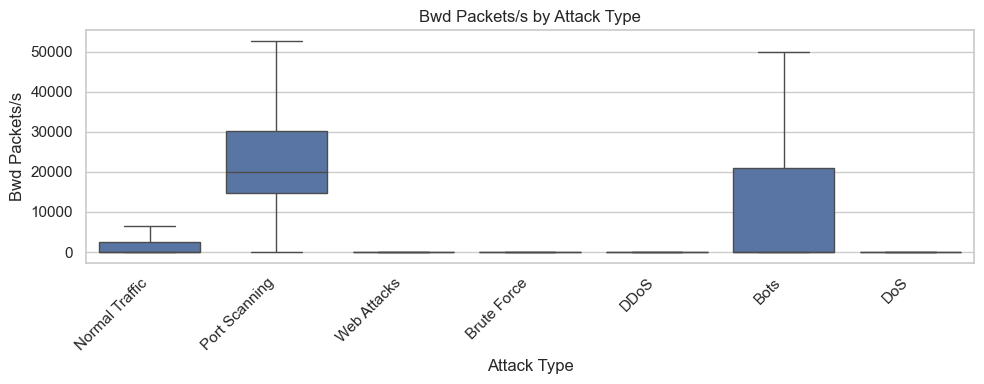

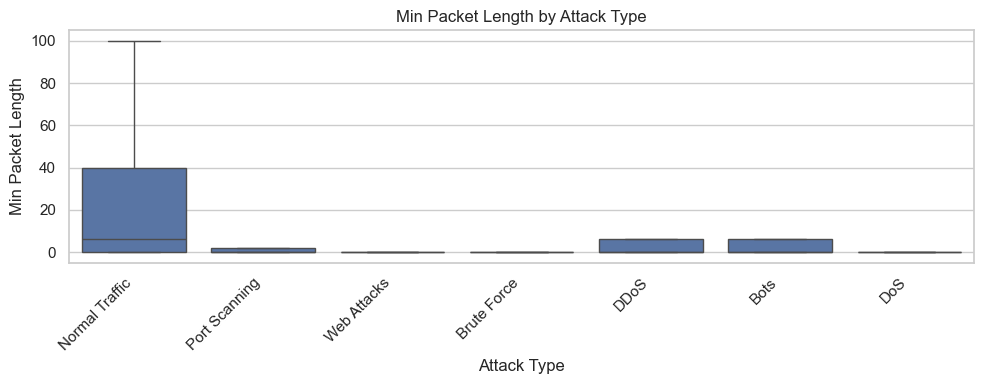

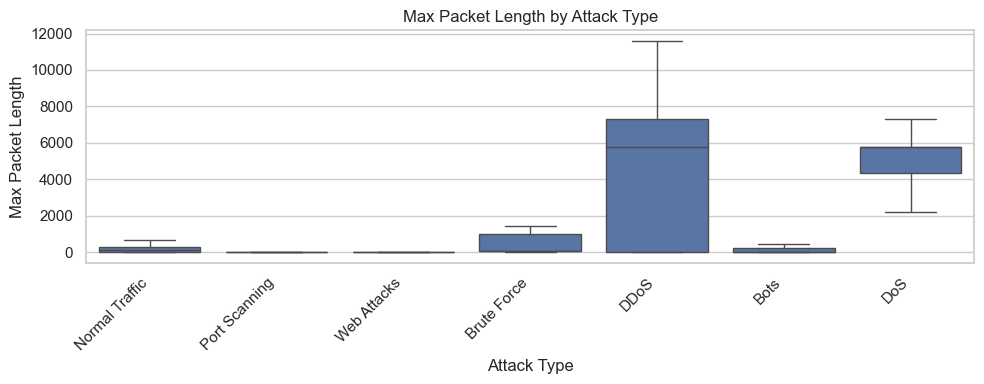

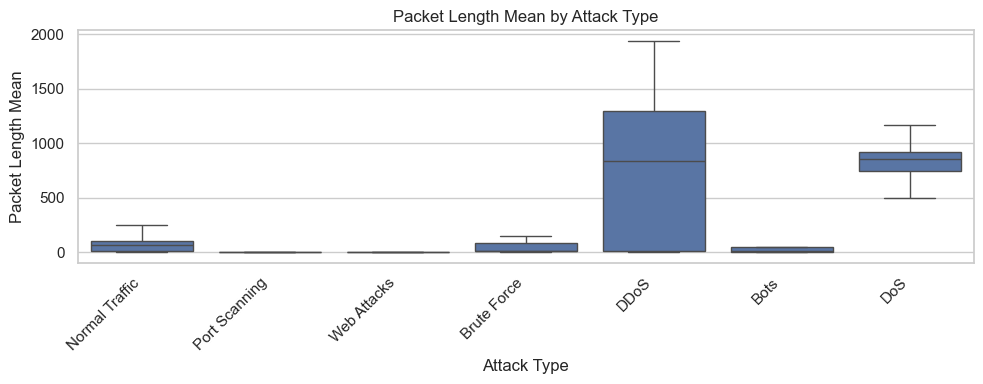

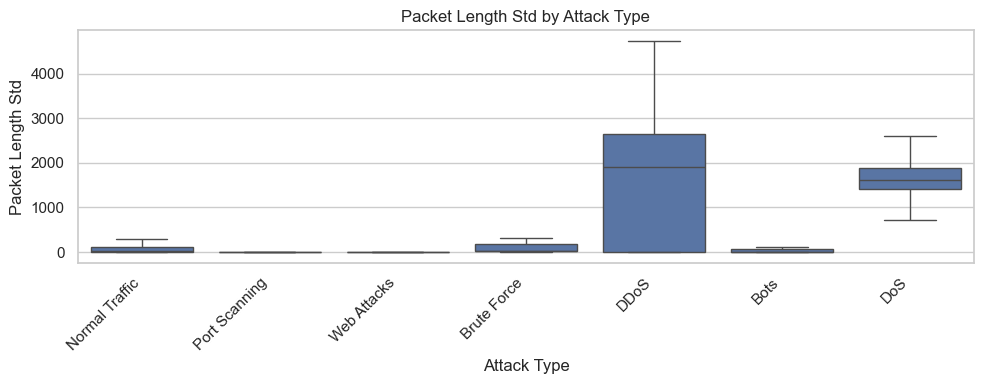

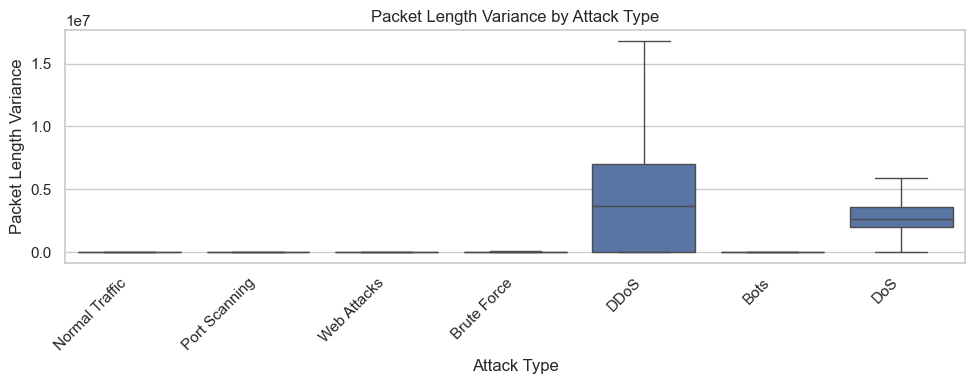

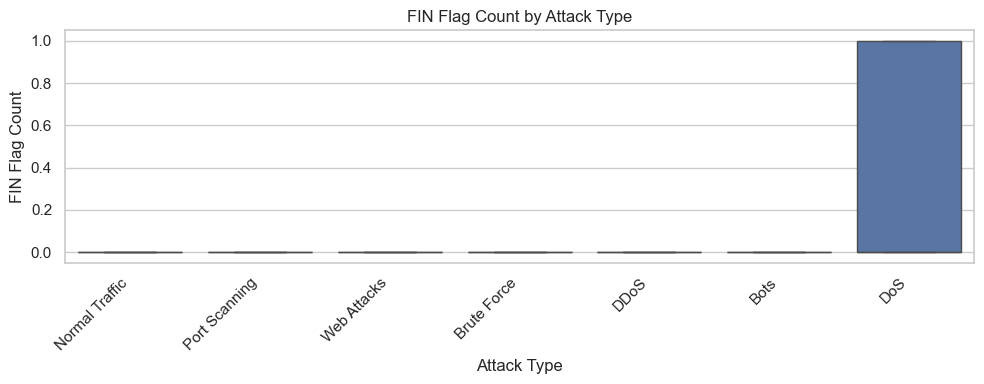

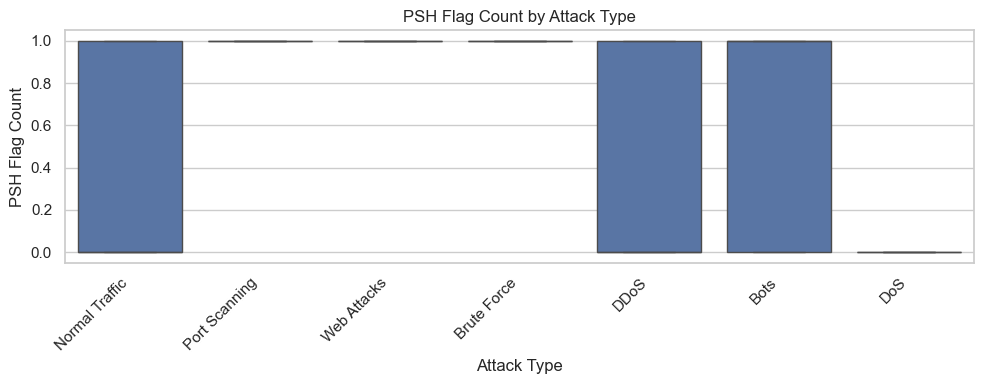

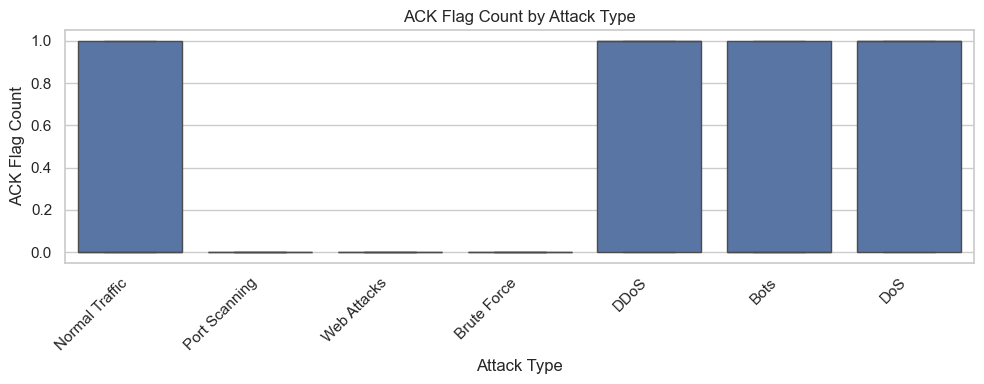

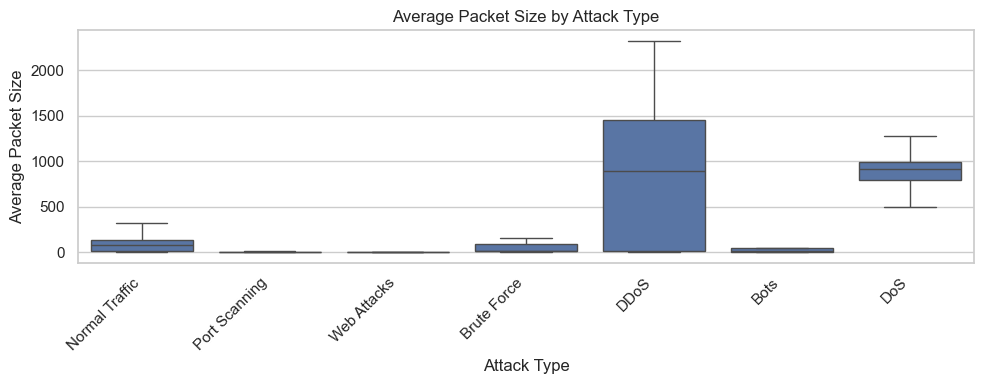

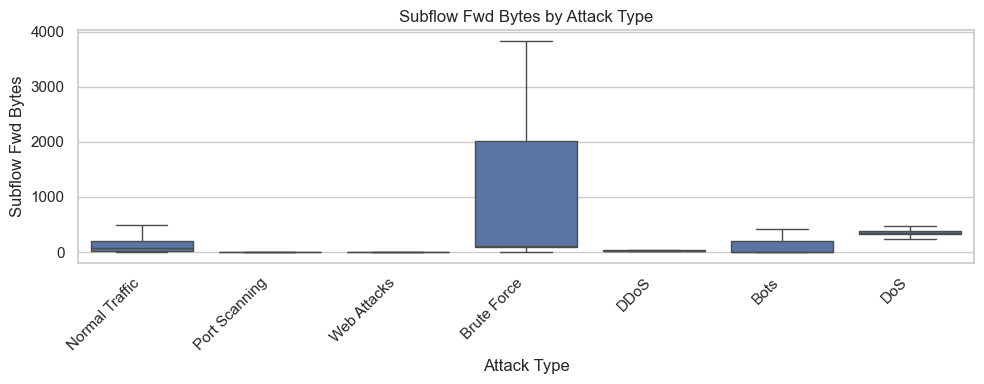

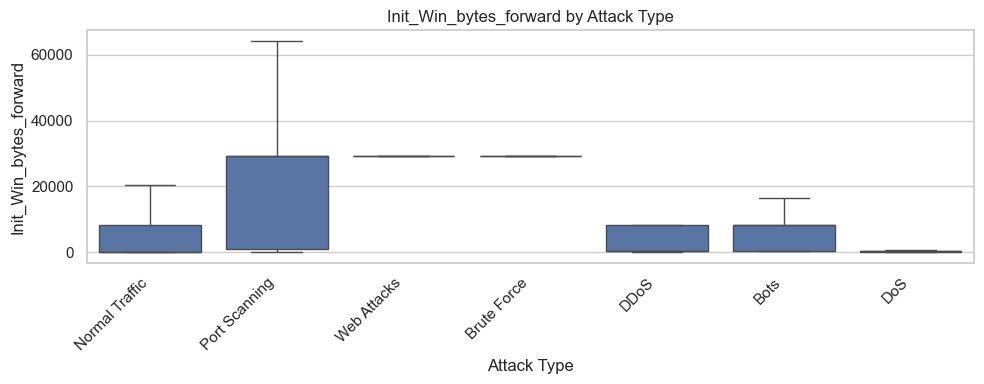

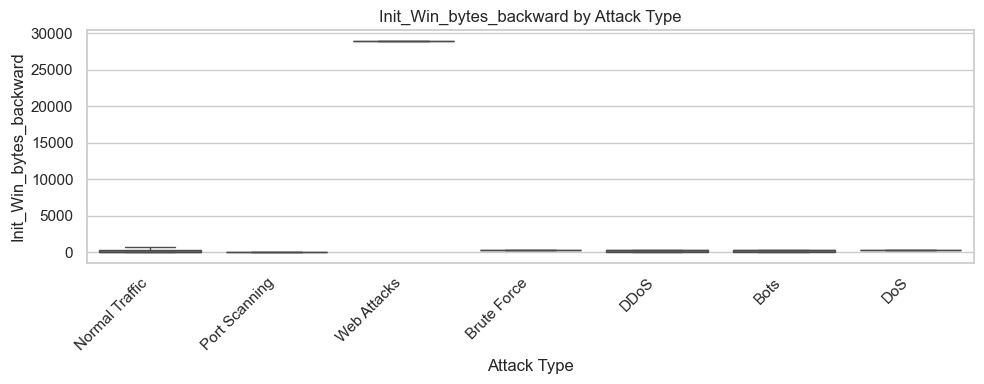

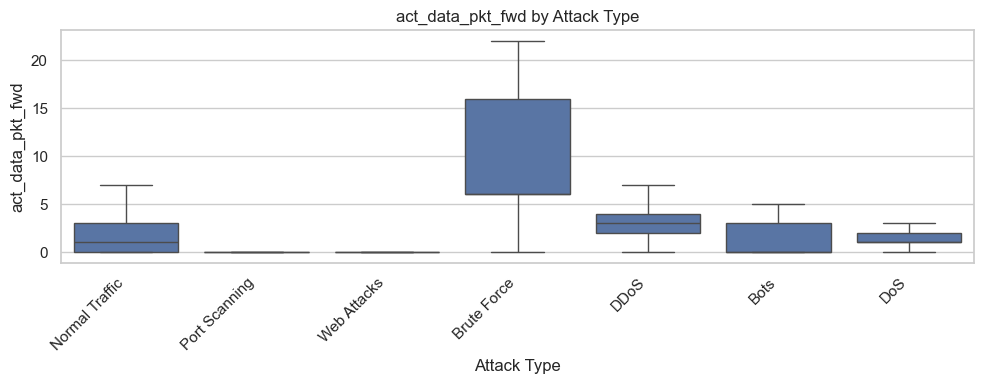

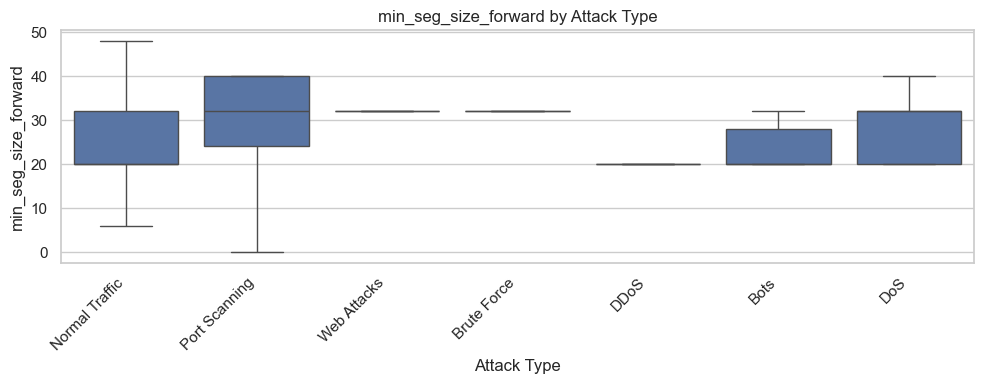

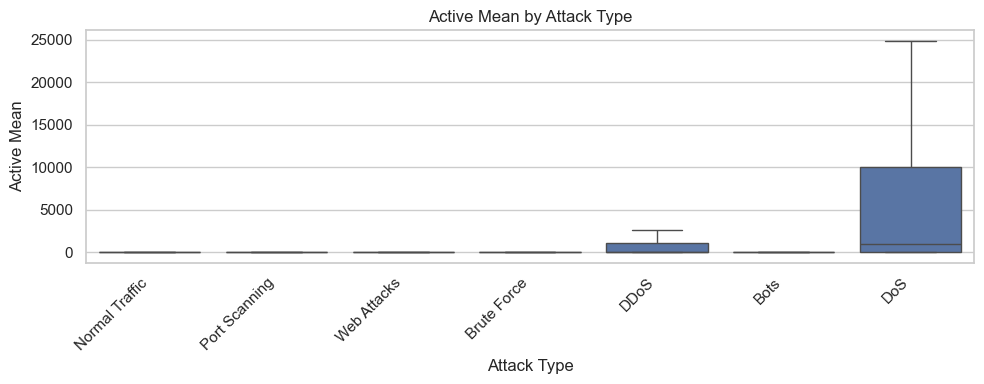

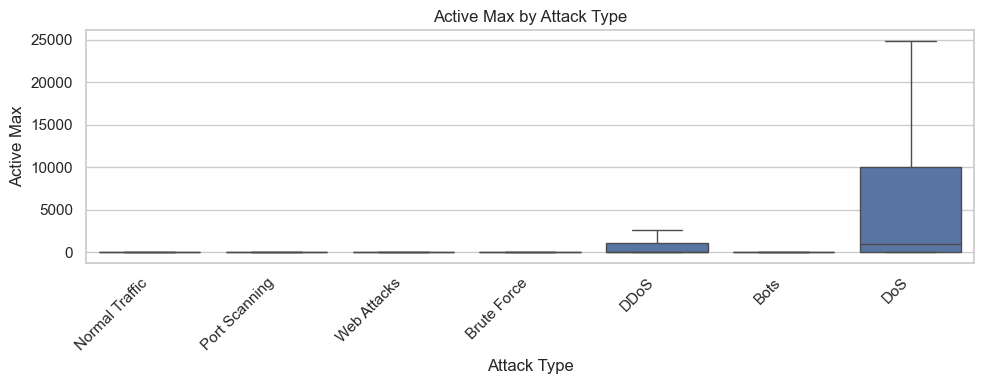

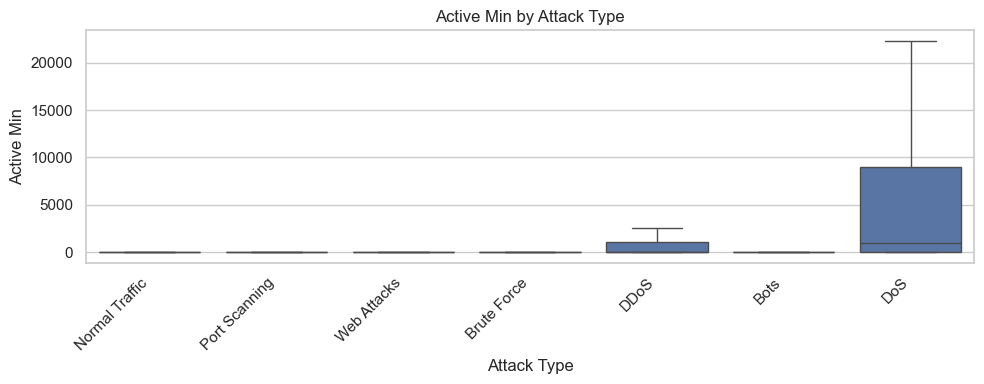

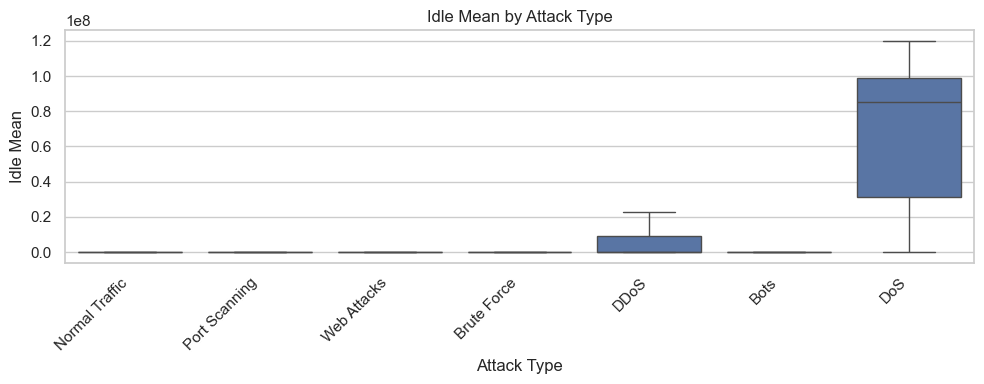

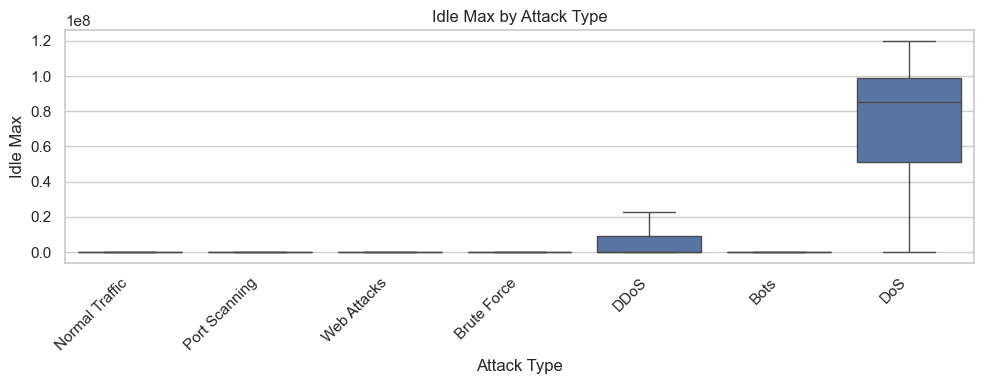

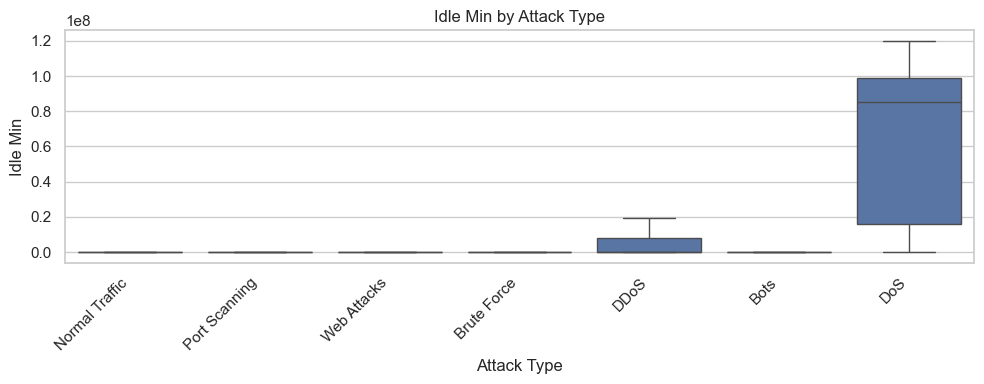

In [21]:
# Boxplots for a few key features grouped by label (helps see separation)
# key_features = num_cols[:6] # pick manually once you know the feature names
key_features = num_cols
for col in key_features:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df, x=TARGET_COL, y=col, showfliers=False)
    plt.title(f"{col} by {TARGET_COL}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


In [22]:
print(num_cols)

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Active Mean', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Max', 'Id

### 6. Correlations and multicollinearity

In [23]:
corr = df[num_cols].corr()
print(corr.shape)   # should show (27, 27)
print(set(num_cols) - set(corr.columns))


(52, 52)
set()


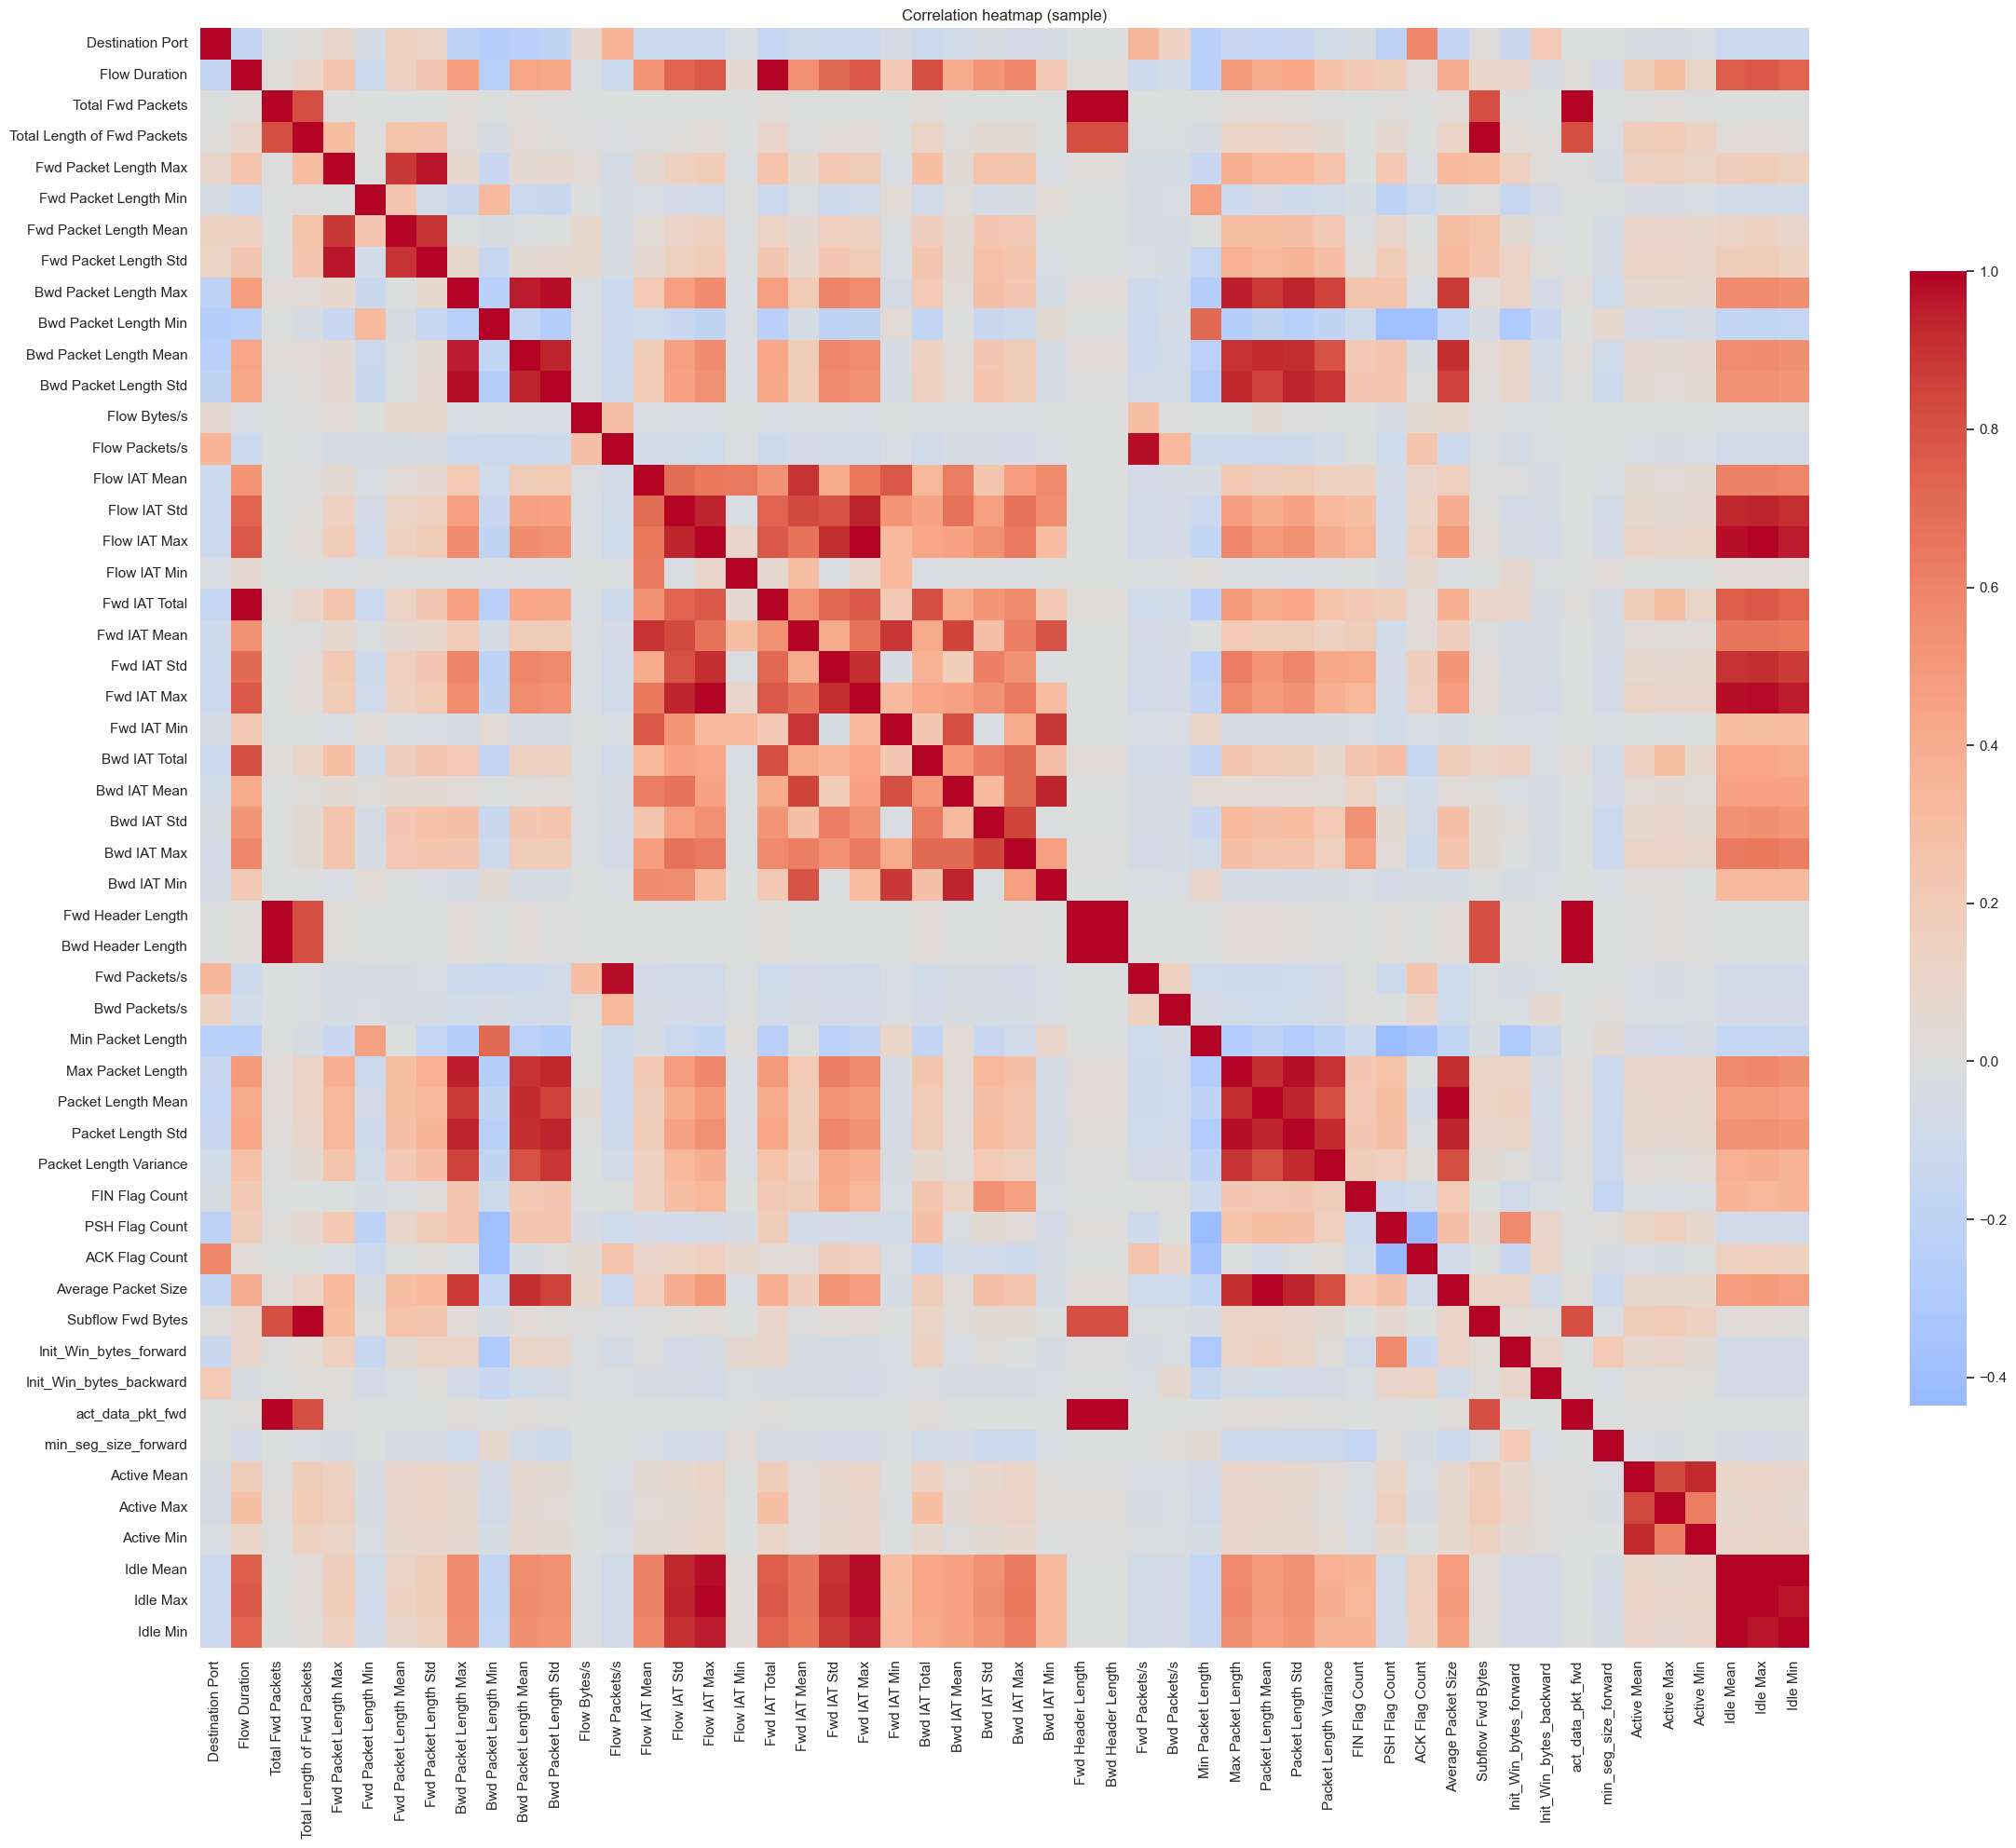

In [24]:
sample_size = 100_000 
df_sample = df.sample(n=min(sample_size, len(df)), random_state=42)

corr = df_sample[num_cols].corr()

plt.figure(figsize=(24, 20))
sns.heatmap(corr, cmap="coolwarm", center=0, 
            square=False, cbar_kws={"shrink": 0.7})
plt.title("Correlation heatmap (sample)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Correlation Heatmap Summary
The correlation heatmap provides a visual overview of relationships among the 52 numerical features in the dataset. Each cell represents the Pearson correlation coefficient between two attributes, with red indicating strong positive correlation, blue indicating strong negative correlation, and lighter shades representing weaker or near‑zero relationships.
Key observations:
- Clusters of strong positive correlations
- Packet length–related features (Fwd Packet Length Max, Min, Mean, Std; Bwd Packet Length counterparts; Packet Length Mean, Variance, Average Packet Size) are highly inter‑correlated, reflecting redundancy in how packet size information is captured.
- Flow timing features (Flow IAT Mean, Std, Max, Min; Fwd/Bwd IAT metrics) also form a correlated group, showing consistent relationships across inter‑arrival time statistics.
- Moderate negative correlations
- Certain timing features (e.g., Idle Max, Idle Mean) show negative associations with packet‑based measures, suggesting inverse relationships between traffic idleness and packet activity.
- Independent features
- Attributes such as Destination Port, FIN/PSH/ACK Flag Counts, Init_Win_bytes_forward/backward exhibit weak or near‑zero correlations with most other variables, indicating they provide unique information not captured by packet length or timing statistics.
Implications for analysis:
- The heatmap highlights multicollinearity among packet length and timing features, which may require dimensionality reduction or feature selection to avoid redundancy in modeling.
- Features with weak correlations (e.g., port numbers, flag counts) are valuable for capturing complementary aspects of network traffic.
- Overall, the visualization helps identify which attributes are strongly related and which contribute independent signals, guiding feature engineering for anomaly detection or attack classification.

Would you like me to also draft a shorter, one‑paragraph version of this summary for an executive‑style report section, so you can use both depending on your audience?


In [25]:
df.to_csv('cicids2017_eda.csv', index=False)